In [ ]:
#Write a program on Support Vector Machine (SVM) : Support Vector Classification (SVC) (using IRIS dataset)
#Step 1 : Importing Necessary Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [ ]:
#Step 2 : Load the iris dataset
iris = load_iris()
print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [ ]:
#Step 3 : Convert to DataFrame for convenience
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
#Export the iris dataset as an excel chart
df.iloc[0:1000].to_excel('iris_v0.xlsx', index = True)

In [ ]:
#As the target variable (species name) column is missing so we need to insert :
df['species'] = iris.target

In [ ]:
#Export all the rows to a Excel file (XLSX Format)
df.iloc[0:1000].to_excel('iris_v1.xlsx', index = True)

In [ ]:
#Map target values to species names for better understanding
df['species'] = df['species'].map({0:'setosa', 1:'versicolor', 2:'virginica'})

In [ ]:
#Export all the rows to a Excel file (XLSX)
df.iloc[0:1000].to_excel('iris_v2.xlsx', index = True)

In [ ]:
#Step 4 : Features and target
X = df.drop('species', axis=1)
y = df['species']

In [ ]:
#Step 5 : Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.7, random_state = 52)

In [ ]:
#Step 6 : Create am SVM model
svm = SVC()

In [ ]:
#Step 7 : Fit the model to the training data
svm.fit(X_train, y_train)

SVC()

In [ ]:
#Step 8 : Predict using the test set
y_pred = svm.predict(X_test)
#print(y_pred)

In [ ]:
#Step 9 : Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[30,  0,  0],
       [ 0, 34,  2],
       [ 0,  5, 34]])

In [ ]:
#Step 10 : Generate classification report & accuracy score
class_report = classification_report(y_test, y_pred)
acc_score = accuracy_score(y_test, y_pred)

#All printing operations
print("Confusion Matrix : \n", cm)
print("\nClassification Report : \n", class_report)
print(f"Accuracy Score = {acc_score*100:.2f}%")

Confusion Matrix : 
 [[30  0  0]
 [ 0 34  2]
 [ 0  5 34]]

Classification Report : 
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        30
  versicolor       0.87      0.94      0.91        36
   virginica       0.94      0.87      0.91        39

    accuracy                           0.93       105
   macro avg       0.94      0.94      0.94       105
weighted avg       0.94      0.93      0.93       105

Accuracy Score = 93.33%


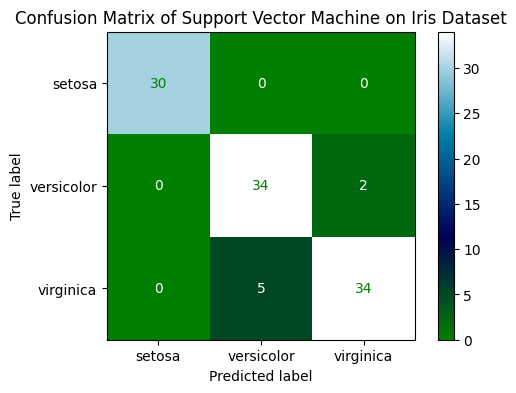

In [ ]:
#Step 11 : Plot the confusion matrix, Set figure size
fig, ax = plt.subplots(figsize=(6,4))

#Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = svm.classes_)
disp.plot(cmap = 'ocean', ax = ax)
plt.title("Confusion Matrix of Support Vector Machine on Iris Dataset")
plt.show()

In [ ]:
#Step 12 : Define the parameter grid
param_grid = {'C':[0.1,1,10,100], 'kernel': ['linear', 'poly', 'rbf', 'sigmold'], 'gamma':['scale', 'auto']}

In [ ]:
#Step 13 : Create a GridSearchCv object, Support Vector Classifier (SVC)
grid_search = GridSearchCV(SVC(), param_grid, cv = 5, scoring = 'accuracy')

In [ ]:
#Step 14 : Fit the grid search to the data
grid_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
40 fits failed out of a total of 160.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmold']},
             scoring='accuracy')

In [ ]:
#Step 15 : Print the best parameters and the best score
print("Best Parameters:\n ", grid_search.best_params_)
print(f"\nBest Cross Validation Score :  {grid_search.best_score_*100:.2f}%")

Best Parameters:
  {'C': 0.1, 'gamma': 'scale', 'kernel': 'poly'}

Best Cross Validation Score :  100.00%


In [ ]:
#Step 16 : Predict with the best estimator
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test)

In [ ]:
#Step 17 : Calculate confusion matrix for the best estimator
cm_best = confusion_matrix(y_test, y_pred)
print(cm_best)

[[30  0  0]
 [ 0 34  2]
 [ 0  5 34]]


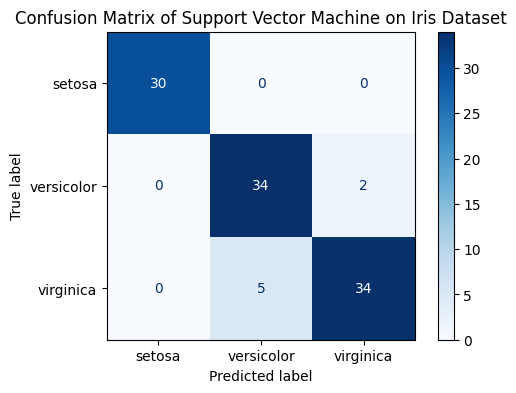

In [ ]:
#Step 18 : Plot the confusion matrix, Set figure size
fig, ax = plt.subplots(figsize=(6,4))

#Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix = cm_best, display_labels = svm.classes_)
disp.plot(cmap = 'Blues', ax = ax)
plt.title("Confusion Matrix of Support Vector Machine on Iris Dataset")
plt.show()

In [ ]:
#Step 19 : Generate classification report & accuracy score for the best estimator
class_report_best = classification_report(y_test, y_pred_best)
acc_score_best = accuracy_score(y_test, y_pred_best)
print("Confusion Matrix (Best Estimator) : \n", cm_best)
print("\n Classification Report (Best Estimator) : \n", class_report_best)
print(f"Accuracy Score (Improved) = {acc_score_best*100:.2f}%")

Confusion Matrix (Best Estimator) : 
 [[30  0  0]
 [ 0 34  2]
 [ 0  5 34]]

 Classification Report (Best Estimator) : 
               precision    recall  f1-score   support

      setosa       0.97      1.00      0.98        30
  versicolor       0.94      0.92      0.93        36
   virginica       0.95      0.95      0.95        39

    accuracy                           0.95       105
   macro avg       0.95      0.96      0.95       105
weighted avg       0.95      0.95      0.95       105

Accuracy Score (Improved) = 95.24%
